# LTMM lab-walk exploration

Quick look at the subject table, label derivation, feature matrix, and headline LOSO results produced by `src/load.py`, `src/features.py`, and `src/train.py`. Run those scripts first -- this notebook only reads their cached outputs, it does not recompute anything.

See the repo README for why these are self-reported, retrospective fall labels (not a fall-prediction model), and for the honest read on the weak AUC below.

In [1]:
import sys, json
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))

import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent
subject_table = pd.read_parquet(ROOT / "data/cache/subject_table.parquet")
features = pd.read_parquet(ROOT / "data/cache/features_labwalks.parquet")
metrics = json.loads((ROOT / "results/metrics.json").read_text())
subject_table.shape, features.shape

((81, 16), (643, 75))

## Source coverage: who has what

In [2]:
coverage = pd.DataFrame({
    "has_3day": [subject_table.has_3day.sum()],
    "has_labwalk": [subject_table.has_labwalk.sum()],
    "has_demographics": [subject_table.has_demographics.sum()],
    "faller_label_known": [subject_table.faller_label_known.sum()],
    "total_unique_subjects": [len(subject_table)],
})
coverage

,has_3day,has_labwalk,has_demographics,faller_label_known,total_unique_subjects
0,71,73,77,76,81


In [3]:
labeled = subject_table[subject_table.faller_label_known]
labeled.is_faller.value_counts().rename({True: "faller (>=2 falls/yr)", False: "non-faller"})

is_faller
non-faller               44
faller (>=2 falls/yr)    32
Name: count, dtype: int64

## Feature matrix sanity check: missingness

In [4]:
num_cols = features.select_dtypes("number").columns
nan_frac = features[num_cols].isna().mean().sort_values(ascending=False)
nan_frac[nan_frac > 0]

falls_year    0.055988
age           0.055988
dtype: float64

## One feature by label, as a spot check (cadence)

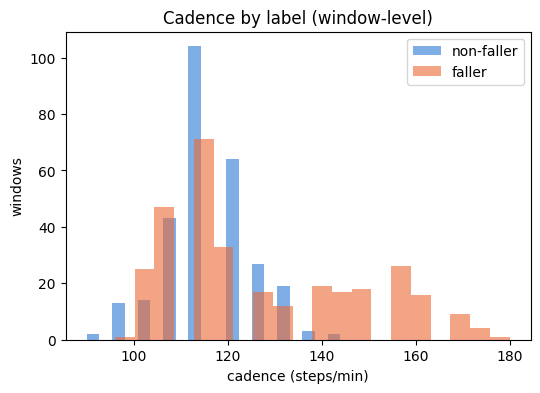

In [5]:
labeled_windows = features[features.faller_label_known]
fig, ax = plt.subplots(figsize=(6, 4))
for label, name, color in [(False, "non-faller", "#2a78d6"), (True, "faller", "#eb6834")]:
    ax.hist(labeled_windows.loc[labeled_windows.is_faller == label, "cadence"].dropna(), bins=20, alpha=0.6, label=name, color=color)
ax.set_xlabel("cadence (steps/min)"); ax.set_ylabel("windows"); ax.legend(); ax.set_title("Cadence by label (window-level)")
plt.show()

## Headline LOSO results (from `src/train.py`)

In [6]:
print("Full 66-feature model, subject-level LOSO:")
print(json.dumps(metrics["full_feature_model_loso"]["subject_level"], indent=2))
print("\nDeployed 10-feature model, subject-level LOSO:")
print(json.dumps(metrics["deployed_model"]["loso_subject_level"], indent=2))

Full 66-feature model, subject-level LOSO:
{
  "auc_roc": 0.4254385964912281,
  "sensitivity": 0.3333333333333333,
  "specificity": 0.5,
  "precision": 0.3448275862068966,
  "confusion_matrix": {
    "tn": 19,
    "fp": 19,
    "fn": 20,
    "tp": 10
  },
  "n": 68
}

Deployed 10-feature model, subject-level LOSO:
{
  "subject_auc_roc": 0.5921052631578947,
  "subject_sensitivity": 0.5333333333333333,
  "subject_specificity": 0.6052631578947368,
  "subject_precision": 0.5161290322580645,
  "subject_confusion_matrix": {
    "tn": 23,
    "fp": 15,
    "fn": 14,
    "tp": 16
  },
  "subject_n": "68"
}


In [7]:
ablation = pd.read_csv(ROOT / "results/ablation.csv")
ablation[["feature_set", "n_features", "subject_auc_roc", "subject_sensitivity", "subject_specificity"]]

,feature_set,n_features,subject_auc_roc,subject_sensitivity,subject_specificity
0,all,66,0.425439,0.333333,0.500000
1,top_10,10,0.592105,0.533333,0.605263
2,top_20,20,0.578947,0.500000,0.578947
3,top_40,40,0.453509,0.366667,0.552632
